#### OVERALL PIPELINE 
##### Data Understanding
##### Preprocessing (proper pipeline)
##### Feature Engineering
##### Model Training (multiple models)
##### Hyperparameter Tuning
##### Threshold Optimization
##### Evaluation (Recall + ROC-AUC)
##### Final Model Selection
##### Save Model
##### Deploy / GitHub

Import dependencies

In [43]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,recall_score,precision_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
heart_data=pd.read_csv("../data/heart.csv")

In [45]:
heart_data.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [46]:
heart_data.tail(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
908,63,M,ASY,140,187,0,LVH,144,Y,4.0,Up,1
909,63,F,ASY,124,197,0,Normal,136,Y,0.0,Flat,1
910,41,M,ATA,120,157,0,Normal,182,N,0.0,Up,0
911,59,M,ASY,164,176,1,LVH,90,N,1.0,Flat,1
912,57,F,ASY,140,241,0,Normal,123,Y,0.2,Flat,1
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [47]:
heart_data.shape

(918, 12)

In [48]:
heart_data.info()
# No null valuesint the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [49]:
heart_data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [50]:
heart_data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [51]:
#Checking the distribution of Target Variable

heart_data["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [52]:
# Age groups
heart_data["AgeGroup"] = pd.cut(heart_data["Age"], bins=[0,40,55,100], labels=["Young","Mid","Old"])

# Binary health indicators
heart_data["HighBP"] = (heart_data["RestingBP"] > 140).astype(int)
heart_data["HighChol"] = (heart_data["Cholesterol"] > 240).astype(int)

In [53]:
heart_data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup,HighBP,HighChol
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,Young,0,1
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,Mid,1,0
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,Young,0,1
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,Mid,0,0
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,Mid,1,0


In [54]:
X= heart_data.drop(columns="HeartDisease",axis=1)
y= heart_data["HeartDisease"]

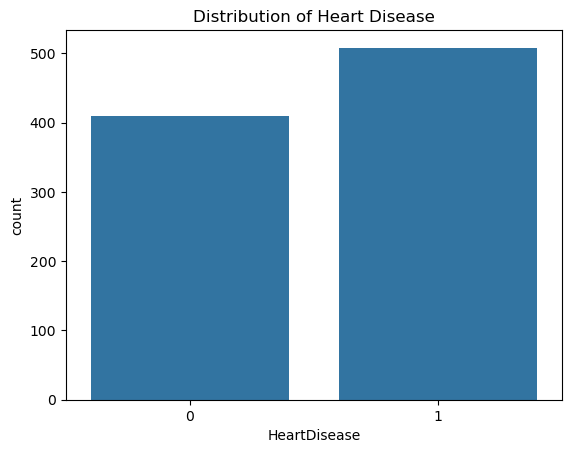

In [84]:
sns.countplot(x="HeartDisease", data=heart_data)
plt.title("Distribution of Heart Disease")
plt.show()

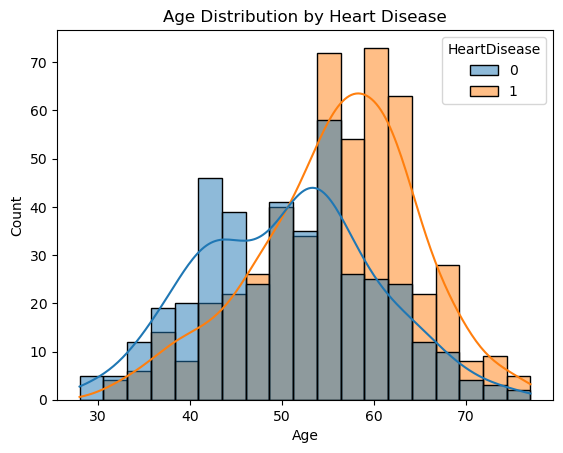

In [89]:
sns.histplot(data=heart_data, x="Age", hue="HeartDisease", kde=True)
plt.title("Age Distribution by Heart Disease")
plt.show()

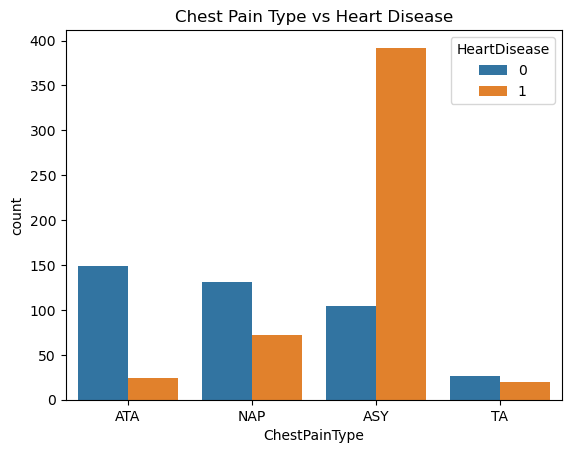

In [88]:
sns.countplot(x="ChestPainType", hue="HeartDisease", data=heart_data)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

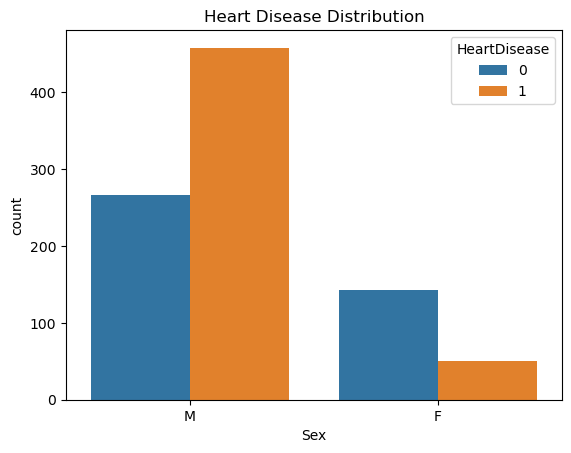

In [93]:
sns.countplot(x="Sex",data=heart_data,hue="HeartDisease")
plt.title("Heart Disease Distribution")
plt.show()

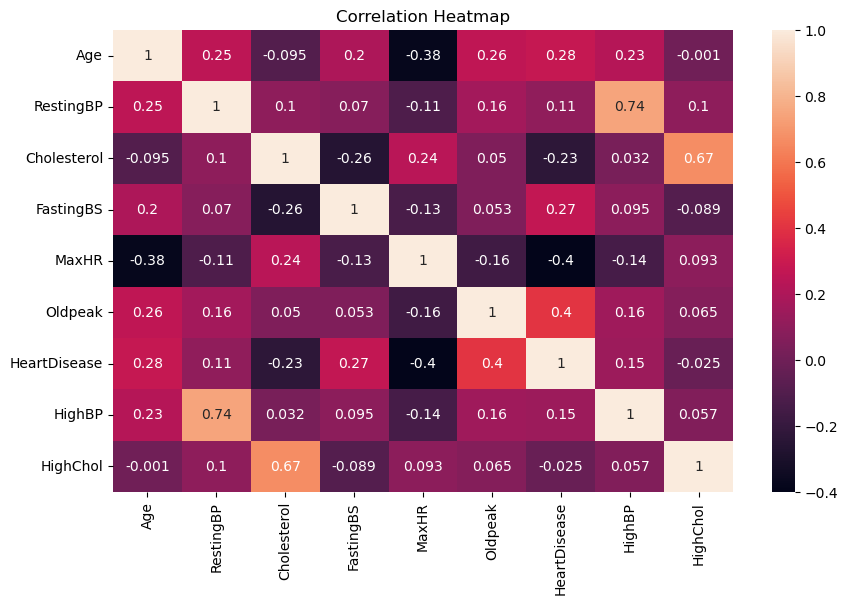

In [96]:
plt.figure(figsize=(10,6))
sns.heatmap(heart_data.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [56]:
numeric_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

categorical_features = [
    "Sex", "ChestPainType", "RestingECG",
    "ExerciseAngina", "ST_Slope", "AgeGroup"
]

In [57]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

Logistic Regression

In [58]:
from sklearn.pipeline import Pipeline
log_model = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

Random Forest

In [59]:
rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

SVC

In [60]:
svm_model = Pipeline([
    ("prep", preprocessor),
    ("model", SVC(probability=True))
])

XGBoost

In [61]:
xgb_model = Pipeline([
    ("prep", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

In [62]:
def evaluate(model, X, y, name):
    y_pred = model.predict(X)
    
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y, y_pred))
    print("Recall:", recall_score(y, y_pred))
    print("Precision:", precision_score(y, y_pred))

In [73]:
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "XGBoost": xgb_model,
}

for name, model in models.items():
    model.fit(X_train, y_train)
    evaluate(model, X_test, y_test, name)


Logistic Regression
Accuracy: 0.875
Recall: 0.9019607843137255
Precision: 0.8761904761904762

Random Forest
Accuracy: 0.8804347826086957
Recall: 0.9117647058823529
Precision: 0.8773584905660378

SVM
Accuracy: 0.8913043478260869
Recall: 0.9411764705882353
Precision: 0.8727272727272727

XGBoost
Accuracy: 0.8804347826086957
Recall: 0.8823529411764706
Precision: 0.9


In [74]:
svm_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", SVC(probability=True))
])

In [75]:
param_grid = {
    "model__C": [0.5, 1, 5, 10],
    "model__gamma": [0.001, 0.01, 0.05],
    "model__kernel": ["rbf"],
    "model__class_weight": ["balanced"]
}

In [76]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    svm_pipeline,
    param_grid,
    scoring="recall",   # 👈 medical priority
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)
print("Best CV Recall:", grid.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END model__C=0.5, model__class_weight=balanced, model__gamma=0.01, model__kernel=rbf; total time=   0.1s
[CV] END model__C=0.5, model__class_weight=balanced, model__gamma=0.01, model__kernel=rbf; total time=   0.1s
[CV] END model__C=0.5, model__class_weight=balanced, model__gamma=0.01, model__kernel=rbf; total time=   0.1s
[CV] END model__C=0.5, model__class_weight=balanced, model__gamma=0.001, model__kernel=rbf; total time=   0.1s
[CV] END model__C=0.5, model__class_weight=balanced, model__gamma=0.01, model__kernel=rbf; total time=   0.0s
[CV] END model__C=0.5, model__class_weight=balanced, model__gamma=0.001, model__kernel=rbf; total time=   0.1s
[CV] END model__C=0.5, model__class_weight=balanced, model__gamma=0.001, model__kernel=rbf; total time=   0.1s
[CV] END model__C=0.5, model__class_weight=balanced, model__gamma=0.001, model__kernel=rbf; total time=   0.1s
[CV] END model__C=0.5, model__class_weight=balanced, mo

In [77]:
probs = best_model.predict_proba(X_test)
from sklearn.metrics import recall_score, precision_score

for t in [0.5, 0.45, 0.4, 0.35]:
    y_pred = (probs[:,1] > t).astype(int)
    
    print(f"\nThreshold: {t}")
    print("Accuracy Score", accuracy_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    


Threshold: 0.5
Accuracy Score 0.875
Recall: 0.9019607843137255
Precision: 0.8761904761904762

Threshold: 0.45
Accuracy Score 0.8804347826086957
Recall: 0.9411764705882353
Precision: 0.8571428571428571

Threshold: 0.4
Accuracy Score 0.8695652173913043
Recall: 0.9411764705882353
Precision: 0.8421052631578947

Threshold: 0.35
Accuracy Score 0.8641304347826086
Recall: 0.9411764705882353
Precision: 0.8347826086956521


The final model we are

In [82]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

probs = svm_model.predict_proba(X_test)

print("Recall", recall_score(y_test, svm_model.predict(X_test)))
print("Precision", precision_score(y_test, svm_model.predict(X_test)))
print("Accuracy", accuracy_score(y_test, svm_model.predict(X_test)))
print(classification_report(y_test, svm_model.predict(X_test)))
print(confusion_matrix(y_test, model.predict(X_test)))
print("ROC-AUC:", roc_auc_score(y_test, probs[:,1]))

Recall 0.9411764705882353
Precision 0.8727272727272727
Accuracy 0.8913043478260869
              precision    recall  f1-score   support

           0       0.92      0.83      0.87        82
           1       0.87      0.94      0.91       102

    accuracy                           0.89       184
   macro avg       0.90      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184

[[72 10]
 [12 90]]
ROC-AUC: 0.9371114299378288


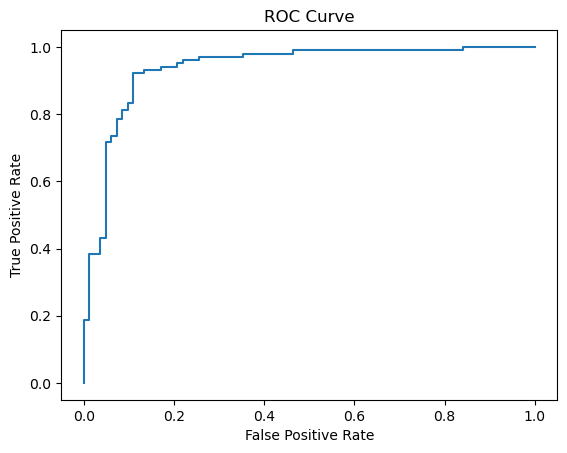

In [83]:

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, probs[:,1])

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

##### Compared 4 models (Logistic, RF, SVM, XGBoost)
##### Selected SVM based on highest recall
##### Tried hyperparameter tuning
##### Evaluated threshold tuning
##### Concluded default threshold is optimal
##### Achieved ~94% recall

Developed a heart disease prediction model using multiple ML algorithms and selected SVM based on superior recall (~94%) for detecting disease cases. Performed hyperparameter tuning and threshold analysis, achieving ~89% accuracy and balanced precision.

In [98]:
X.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,AgeGroup,HighBP,HighChol
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,Young,0,1
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,Mid,1,0
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,Young,0,1
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,Mid,0,0
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,Mid,1,0


In [102]:
input_data = pd.DataFrame({
    "Age": [37],
    "Sex": ["M"],
    "ChestPainType": ["ATA"],
    "RestingBP": [130],
    "Cholesterol": [283],
    "FastingBS": [0],
    "RestingECG": ["ST"],
    "MaxHR": [98],
    "ExerciseAngina": ["N"],
    "Oldpeak": [0.0],
    "ST_Slope": ["Up"],
    "AgeGroup": ["Young"]
})
prediction = svm_model.predict(input_data)
print("Predicted Class:", prediction[0])
probs = svm_model.predict_proba(input_data)
print("Probability of Heart Disease:", probs[0][1])

Predicted Class: 0
Probability of Heart Disease: 0.26520061755020125


In [104]:
if prediction[0] == 1:
    print("The patient has heart disease.")
else:    print("The patient does not have heart disease.")

The patient does not have heart disease.
